# Progetto — Classificazione della qualità del vino rosso (con Data Augmentation)

L'obiettivo è costruire un modello di classificazione per predire la qualità del vino rosso (`WineQuality`) a partire dalle caratteristiche fisico-chimiche.

Il problema è multiclass: la qualità può assumere valori da 3 a 8.

Poiché alcune classi sono fortemente sbilanciate, applichiamo un **oversampling** delle classi minoritarie usando `sklearn.utils.resample`, portando tutte le classi allo stesso numero di esempi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

## Lettura dei dati

Carichiamo il dataset di training e il dataset di test.

In [2]:
train = pd.read_excel("wine_train.xlsx")
test = pd.read_excel("wine_test.xlsx")

# Rimuoviamo eventuali spazi nei nomi delle colonne
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

train.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Synthetic_Noise_Flag,Alcohol_Density_Ratio,Volatile_Enhanced,WineQuality
0,7.1,0.45,0.62,6.5,0.012,25,71,1.0013,3.49,0.93,9.1,6.436419,0,9.016522,0,6
1,9.3,0.54,0.43,7.4,0.012,17,76,0.9953,3.31,0.65,11.5,NaN,0,11.667603,0,5
2,8.8,0.45,0.28,1.2,0.090,15,24,0.9956,3.53,0.74,9.8,6.597745,0,NaN,0,5
3,11.1,0.48,0.45,5.6,0.102,12,79,0.9964,3.21,0.52,10.8,5.719312,1,11.304956,0,6
4,9.2,0.61,0.00,4.9,0.155,9,54,0.9945,3.29,0.73,9.4,6.662838,0,10.164500,1,6


## Separazione tra feature e target

Separiamo:

- `X`: variabili predittive;
- `y`: variabile target `WineQuality`.

Rimuoviamo le colonne binarie sintetiche `Synthetic_Noise_Flag` e `Volatile_Enhanced`, che non utilizzeremo.

In [3]:
X = train.drop(columns=["WineQuality", "Synthetic_Noise_Flag", "Volatile_Enhanced"])
y = train["WineQuality"]

print("Distribuzione originale delle classi:")
print(y.value_counts().sort_index())

Distribuzione originale delle classi:
WineQuality
3      3
4     40
5    438
6    409
7    121
8     13
Name: count, dtype: int64


## Preprocessing

Gestiamo i valori mancanti imputandoli con la media di ciascuna colonna.

L'imputer verrà salvato e riutilizzato sul test set.

In [4]:
X_clean = X.copy()

# Colonne numeriche su cui applicare l'imputazione
numeric_cols = X_clean.select_dtypes(include=["float64", "int64"]).columns

imputer = SimpleImputer(strategy="mean")
X_clean[numeric_cols] = imputer.fit_transform(X_clean[numeric_cols])

print("Valori mancanti dopo l'imputazione:")
print(X_clean.isnull().sum())
X_clean.head()

Valori mancanti dopo l'imputazione:
fixed_acidity                 0
volatile_acidity              0
citric_acid                   0
residual_sugar                0
chlorides                     0
free_sulfur_dioxide           0
total_sulfur_dioxide          0
density                       0
pH                            0
sulphates                     0
alcohol                       0
Acidity_Sulfur_Interaction    0
Alcohol_Density_Ratio         0
dtype: int64


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Alcohol_Density_Ratio
0,7.1,0.45,0.62,6.5,0.012,25.0,71.0,1.0013,3.49,0.93,9.1,6.436419,9.016522
1,9.3,0.54,0.43,7.4,0.012,17.0,76.0,0.9953,3.31,0.65,11.5,5.476156,11.667603
2,8.8,0.45,0.28,1.2,0.090,15.0,24.0,0.9956,3.53,0.74,9.8,6.597745,10.442825
3,11.1,0.48,0.45,5.6,0.102,12.0,79.0,0.9964,3.21,0.52,10.8,5.719312,11.304956
4,9.2,0.61,0.00,4.9,0.155,9.0,54.0,0.9945,3.29,0.73,9.4,6.662838,10.164500


## Data Augmentation – Bilanciamento delle classi con `resample`

Eseguiamo l'oversampling delle classi minoritarie (3, 4, 7, 8) portandole allo stesso numero di esempi della classe più numerosa (438).

In questo modo tutte le classi avranno lo stesso peso durante l'addestramento.

In [5]:
# Dimensione target: numero massimo di esempi per classe
max_count = y.value_counts().max()

X_balanced = []
y_balanced = []

for label in sorted(y.unique()):
    X_class = X_clean[y == label]
    y_class = y[y == label]
    
    if len(X_class) < max_count:
        # Oversampling con rimpiazzo
        X_res, y_res = resample(X_class, y_class,
                                 replace=True,
                                 n_samples=max_count,
                                 random_state=42)
    else:
        X_res, y_res = X_class, y_class
    
    X_balanced.append(X_res)
    y_balanced.append(y_res)

X_balanced = pd.concat(X_balanced)
y_balanced = pd.concat(y_balanced)

print("Distribuzione dopo augmentation:")
print(y_balanced.value_counts().sort_index())

Distribuzione dopo augmentation:
WineQuality
3    438
4    438
5    438
6    438
7    438
8    438
Name: count, dtype: int64


## Train / Validation split

Dividiamo il dataset bilanciato in addestramento e validazione, mantenendo la stratificazione.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

## Random Forest – Grid Search

Ottimizziamo gli iperparametri della Random Forest tramite Grid Search con validazione incrociata a 3 fold.
Poiché le classi sono state bilanciate, non serve usare `class_weight='balanced'`.

La metrica di riferimento è l'**F1 macro**.

In [7]:
param_grid = {
    "n_estimators": [100, 250, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Migliori parametri:", grid_search.best_params_)
print("Miglior F1 macro (CV media):", grid_search.best_score_)

Migliori parametri: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 250}
Miglior F1 macro (CV media): 0.8347670856630535


## Modello finale e valutazione con cross‑validation

Usiamo il miglior modello per ottenere predizioni via cross‑validation sull'intero dataset bilanciato, così da avere una stima robusta delle prestazioni.

In [8]:
best_model = grid_search.best_estimator_

# Predizioni cross‑validate
y_pred_cv = cross_val_predict(best_model, X_balanced, y_balanced, cv=cv)

accuracy_cv = accuracy_score(y_balanced, y_pred_cv)
precision_cv = precision_score(y_balanced, y_pred_cv, average="macro", zero_division=0)
recall_cv = recall_score(y_balanced, y_pred_cv, average="macro", zero_division=0)
f1_cv = f1_score(y_balanced, y_pred_cv, average="macro", zero_division=0)

print("Accuracy (CV):", accuracy_cv)
print("Precision macro (CV):", precision_cv)
print("Recall macro (CV):", recall_cv)
print("F1 macro (CV):", f1_cv)
print("\nClassification report (CV):")
print(classification_report(y_balanced, y_pred_cv, zero_division=0))

Accuracy (CV): 0.8801369863013698
Precision macro (CV): 0.8799515209292115
Recall macro (CV): 0.8801369863013698
F1 macro (CV): 0.8793476144736617

Classification report (CV):
              precision    recall  f1-score   support

           3       1.00      1.00      1.00       438
           4       0.99      1.00      1.00       438
           5       0.66      0.73      0.69       438
           6       0.72      0.64      0.68       438
           7       0.92      0.92      0.92       438
           8       0.98      1.00      0.99       438

    accuracy                           0.88      2628
   macro avg       0.88      0.88      0.88      2628
weighted avg       0.88      0.88      0.88      2628



## Matrice di confusione (cross‑validation)

La matrice di confusione mostra come vengono predette le singole classi.

In [9]:
classi = sorted(y_balanced.unique())
conf_matrix = confusion_matrix(y_balanced, y_pred_cv, labels=classi)

conf_df = pd.DataFrame(conf_matrix, index=classi, columns=classi)
conf_df.index.name = "Classe reale"
conf_df.columns.name = "Classe predetta"
conf_df

Classe predetta,3,4,5,6,7,8
Classe reale,,,,,,
3,438,0,0,0,0,0
4,0,438,0,0,0,0
5,0,3,318,93,22,2
6,0,0,140,279,14,5
7,0,1,21,14,402,0
8,0,0,0,0,0,438


## Importanza delle feature

Vediamo quali variabili contribuiscono di più alle decisioni del modello.

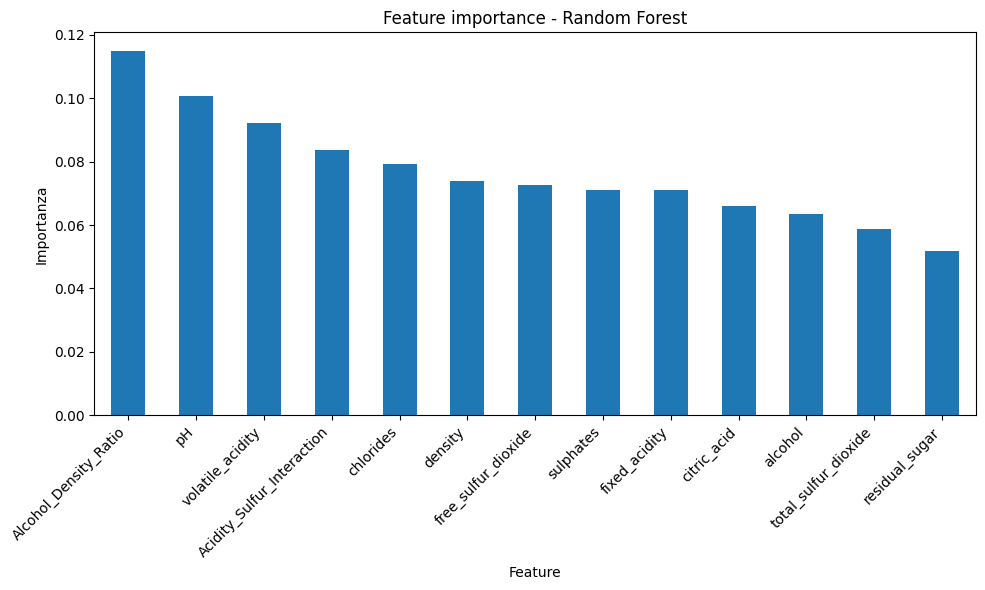

In [10]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_balanced.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind="bar")
plt.title("Feature importance - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importanza")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Preprocessing del dataset di test

Applichiamo le stesse trasformazioni usate per il training (imputazione).
Il test set non viene alterato con augmentation.

In [11]:
test_features = test.copy()

# Se il test contiene la colonna target la rimuoviamo (non serve)
if "WineQuality" in test_features.columns:
    test_features = test_features.drop(columns=["WineQuality", "Synthetic_Noise_Flag", "Volatile_Enhanced"])

# Manteniamo solo le colonne presenti in X_balanced
test_features = test_features[X_balanced.columns]

# Imputazione
test_clean = test_features.copy()
test_clean[numeric_cols] = imputer.transform(test_clean[numeric_cols])

test_clean.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Alcohol_Density_Ratio
0,8.8,0.48,0.66,1.2,0.053,34.0,61.0,0.9967,3.26,0.82,9.5,7.267484,9.089129
1,7.7,0.69,0.09,1.2,0.084,1.0,31.0,0.9944,3.40,0.66,9.6,5.476156,10.513058
2,6.9,0.38,0.13,2.6,0.012,7.0,66.0,0.9949,3.15,0.42,10.9,2.940180,11.104644
3,8.5,0.58,0.01,1.6,0.057,11.0,11.0,0.9957,3.21,0.51,11.2,4.311858,10.890228
4,9.0,0.31,0.52,1.2,0.098,6.0,88.0,0.9954,3.37,0.83,10.0,7.495080,9.389312


## Predizione sul dataset di test

Usiamo il modello addestrato sul dataset bilanciato per predire la qualità dei vini nel test set.

In [12]:
test_predictions = best_model.predict(test_clean)

test["Predicted_WineQuality"] = test_predictions
test.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Synthetic_Noise_Flag,Alcohol_Density_Ratio,Volatile_Enhanced,WineQuality,Predicted_WineQuality
0,8.8,0.48,0.66,1.2,0.053,34,61,0.9967,3.26,0.82,9.5,7.267484,0,9.089129,0,5,6
1,7.7,0.69,0.09,1.2,0.084,1,31,0.9944,3.40,0.66,9.6,NaN,0,10.513058,1,7,5
2,6.9,0.38,0.13,2.6,0.012,7,66,0.9949,3.15,0.42,10.9,2.940180,0,11.104644,0,5,6
3,8.5,0.58,0.01,1.6,0.057,11,11,0.9957,3.21,0.51,11.2,4.311858,0,10.890228,0,6,6
4,9.0,0.31,0.52,1.2,0.098,6,88,0.9954,3.37,0.83,10.0,7.495080,0,9.389312,0,6,5
